Name: Papadopoulos Ioannis-Rafail
AEM: 10696

The code was orignally built in multiple cells for each homework but we were asked to built it in one cell for each homework (thats why many imports may be multiple times) so i just concantenated all of them but  the code might seem too long for one single block.

START OF 'A'

Lets first load our data, make them into a panda dataframe and lets see some visual results from them as well

               X1          X2       Class
count  300.000000  300.000000  300.000000
mean    32.319677   28.641387    1.000000
std      7.425101   10.061984    0.817861
min     13.149767    1.122443    0.000000
25%     26.728744   20.997999    0.000000
50%     31.392079   31.482850    1.000000
75%     38.928159   36.322726    2.000000
max     47.569759   46.062217    2.000000

Statistics for each class:

Class 0 :
  X1: mean = 29.2090, std = 6.8892
  X2: mean = 16.8499, std = 7.0087

Class 1 :
  X1: mean = 40.1977, std = 3.0853
  X2: mean = 34.2811, std = 4.5068

Class 2 :
  X1: mean = 27.5523, std = 3.7563
  X2: mean = 34.7932, std = 5.0541


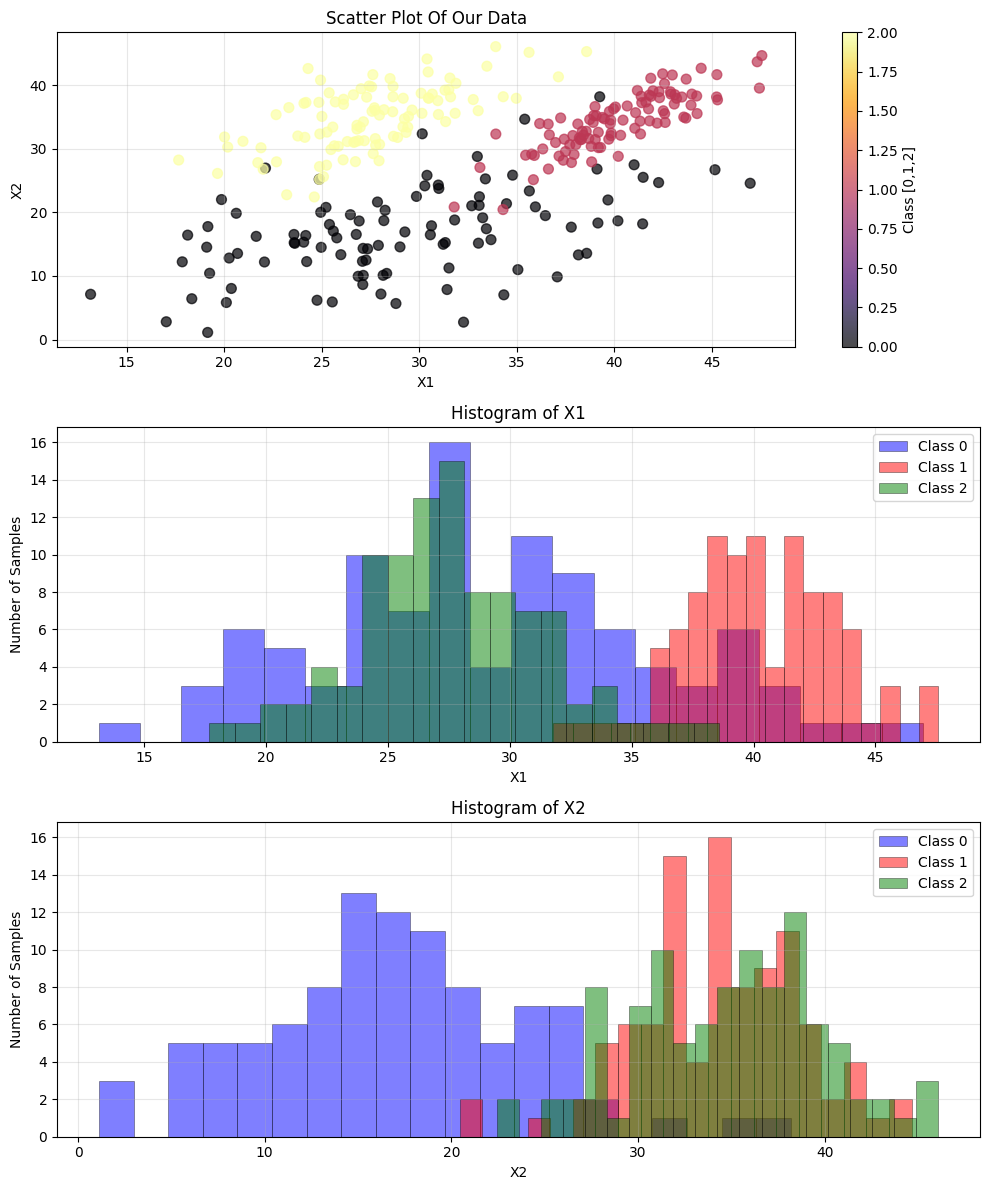

/tmp/ipython-input-3102260788.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(boxplot_data_x1, labels=box_labels_x1, patch_artist=True,
/tmp/ipython-input-3102260788.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(boxplot_data_x2, labels=box_labels_x2, patch_artist=True,


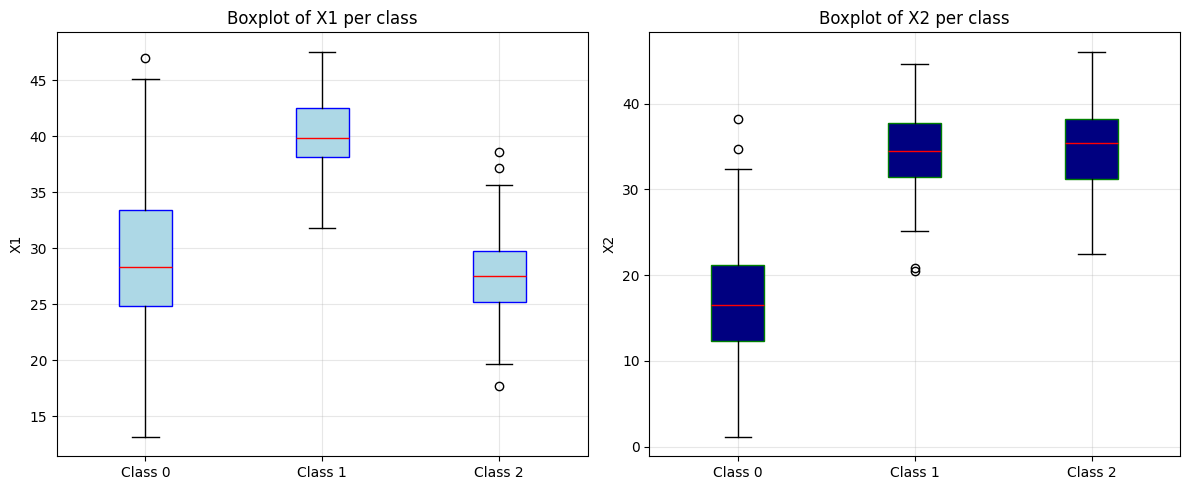


Class 0:
  mean: [29.209038, 16.849889]
  Covariance Matrix Σ:
    [46.985913  22.905323]
    [22.905323  48.631336]

Class 1:
  mean: [40.197669, 34.281091]
  Covariance Matrix Σ:
    [9.423905  11.489718]
    [11.489718  20.108056]

Class 2:
  mean: [27.552325, 34.793180]
  Covariance Matrix Σ:
    [13.968744  11.774336]
    [11.774336  25.288482]


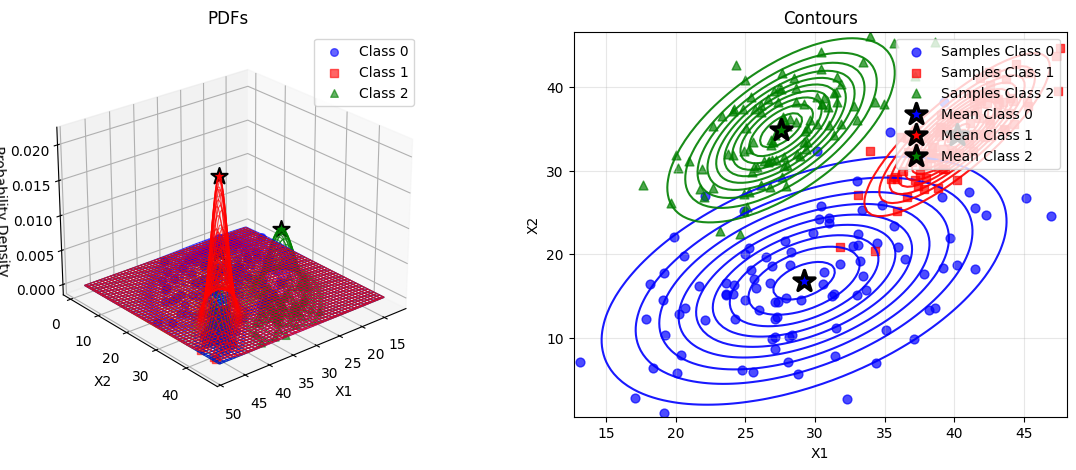

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

#We will make our data into panda dataframe (for easier handling )
df = pd.read_csv('dataset1.csv', header=None, names=['X1', 'X2', 'Class']) #feature X1, feature X2, label-class

print(df.describe())  #a first insight-description of our data (note that the 'statistics' in label dont really matter as '0','1','2' are just encodings )

print("\nStatistics for each class:")
for class_label in sorted(df['Class'].unique()):
    class_data = df[df['Class'] == class_label]
    print(f"\nClass {int(class_label)} :")
    print(f"  X1: mean = {class_data['X1'].mean():.4f}, std = {class_data['X1'].std():.4f}")
    print(f"  X2: mean = {class_data['X2'].mean():.4f}, std = {class_data['X2'].std():.4f}")



    #------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

scatter = axes[0].scatter(df['X1'], df['X2'], c=df['Class'],  #scatter plot for visualization
                         cmap='inferno', alpha=0.7, s=50)
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')
axes[0].set_title('Scatter Plot Of Our Data')
plt.colorbar(scatter, ax=axes[0], label='Class [0,1,2]')
axes[0].grid(True, alpha=0.3)

#scatter plot results match with what we observed earlier about the seperations and the means and std's

colors = ['blue', 'red', 'green']

# histogram for feature X1 and X2

for i, class_label in enumerate(sorted(df['Class'].unique())):
    class_data = df[df['Class'] == class_label]
    axes[1].hist(class_data['X1'], bins=20, alpha=0.5,
                color=colors[i], label=f'Class {int(class_label)}',
                edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('X1')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Histogram of X1')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# same for X2
for i, class_label in enumerate(sorted(df['Class'].unique())):
    class_data = df[df['Class'] == class_label]
    axes[2].hist(class_data['X2'], bins=20, alpha=0.5,
                color=colors[i], label=f'Class {int(class_label)}',
                edgecolor='black', linewidth=0.5)
axes[2].set_xlabel('X2')
axes[2].set_ylabel('Number of Samples')
axes[2].set_title('Histogram of X2')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#------------------------------------------------


# Lets also make a boxplot (all these to see whether they 'match' the pd.describe and have a better visualization of our data)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot X1
boxplot_data_x1 = []
box_labels_x1 = []
for class_label in sorted(df['Class'].unique()):
    boxplot_data_x1.append(df[df['Class'] == class_label]['X1'].values)
    box_labels_x1.append(f'Class {int(class_label)}')

axes[0].boxplot(boxplot_data_x1, labels=box_labels_x1, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='blue'),
               medianprops=dict(color='red'))
axes[0].set_ylabel('X1')
axes[0].set_title('Boxplot of X1 per class')
axes[0].grid(True, alpha=0.3)

# Boxplot of X2
boxplot_data_x2 = []
box_labels_x2 = []
for class_label in sorted(df['Class'].unique()):
    boxplot_data_x2.append(df[df['Class'] == class_label]['X2'].values)
    box_labels_x2.append(f'Class {int(class_label)}')

axes[1].boxplot(boxplot_data_x2, labels=box_labels_x2, patch_artist=True,
               boxprops=dict(facecolor='navy', color='green'),
               medianprops=dict(color='red'))
axes[1].set_ylabel('X2')
axes[1].set_title('Boxplot of X2 per class')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#----------------------------------------------------------------

# Could use first 100,next 100 and final 100 but df['Class']==0 is safer for shuffled data.
class_0 = df[df['Class'] == 0][['X1', 'X2']].values
class_1 = df[df['Class'] == 1][['X1', 'X2']].values
class_2 = df[df['Class'] == 2][['X1', 'X2']].values

# We build a function that estimates the gaussian paramaters-->mean value and covariance matrix
def estimate_gaussian_params(data):
    n = len(data)
    mean = np.sum(data, axis=0) / n # definition of mean value
    centered = data - mean
    cov = (centered.T @ centered) / n  # sum(x-x')(x-x') /N (matrix bcs of x1 and x2 features)
    return mean, cov

params = {}
for i, (class_data, class_name) in enumerate(zip([class_0, class_1, class_2],
                                                ['Class 0', 'Class 1', 'Class 2'])):
    mean, cov = estimate_gaussian_params(class_data) #repeat for each class
    params[class_name] = {'mean': mean, 'cov': cov}

    print(f"\n{class_name}:")
    print(f"  mean: [{mean[0]:.6f}, {mean[1]:.6f}]")
    print(f"  Covariance Matrix Σ:")
    print(f"    [{cov[0, 0]:.6f}  {cov[0, 1]:.6f}]")
    print(f"    [{cov[1, 0]:.6f}  {cov[1, 1]:.6f}]")

#--------------------------------------------------------------------------------------
def multivariate_gaussian_pdf(x, mean, cov):

    d = len(mean)  #number of features
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)  #S^(-1)
    diff = x - mean
    exponent = -0.5 * (diff.T @ inv_cov @ diff) #right term
    normalization = 1.0 / ((2 * np.pi) ** (d/2) * np.sqrt(det_cov))  #left term
    return normalization * np.exp(exponent)

x_min, x_max = df['X1'].min() - 0.5, df['X1'].max() + 0.5
y_min, y_max = df['X2'].min() - 0.5, df['X2'].max() + 0.5
#find the lower and the upper limir and add some 'safe' space for each direction

x = np.linspace(x_min, x_max, 100)
y = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x, y)  #100 values for each

def compute_pdf_grid(mean, cov):
    Z = np.zeros_like(X_grid)
    for i in range(X_grid.shape[0]):
        for j in range(X_grid.shape[1]):
            point = np.array([X_grid[i, j], Y_grid[i, j]])
            Z[i, j] = multivariate_gaussian_pdf(point, mean, cov)
    return Z  #calculating the z values that are the 'height' in our 3d plot

Z0 = compute_pdf_grid(params['Class 0']['mean'], params['Class 0']['cov'])
Z1 = compute_pdf_grid(params['Class 1']['mean'], params['Class 1']['cov'])
Z2 = compute_pdf_grid(params['Class 2']['mean'], params['Class 2']['cov'])

#-----------------------------------------------------------------------------

fig = plt.figure(figsize=(14, 5))

# Plot 1 (gaussian pdfs)
ax1 = fig.add_subplot(121, projection='3d')

# use wireframe bcs thanks to its 'grid' one gaussian does not overshadow another making it hard to see
ax1.plot_wireframe(X_grid, Y_grid, Z0, alpha=0.7, color='blue', linewidth=0.8)
ax1.plot_wireframe(X_grid, Y_grid, Z1, alpha=0.7, color='red', linewidth=0.8)
ax1.plot_wireframe(X_grid, Y_grid, Z2, alpha=0.7, color='green', linewidth=0.8)

ax1.scatter(class_0[:, 0], class_0[:, 1], 0, c='blue', alpha=0.6, s=30, marker='o', label='Class 0')
ax1.scatter(class_1[:, 0], class_1[:, 1], 0, c='red', alpha=0.6, s=30, marker='s', label='Class 1')
ax1.scatter(class_2[:, 0], class_2[:, 1], 0, c='green', alpha=0.6, s=30, marker='^', label='Class 2')

ax1.scatter(params['Class 0']['mean'][0], params['Class 0']['mean'][1],
           Z0.max(), c='blue', s=150, marker='*', edgecolor='black', linewidth=1.5)
ax1.scatter(params['Class 1']['mean'][0], params['Class 1']['mean'][1],
           Z1.max(), c='red', s=150, marker='*', edgecolor='black', linewidth=1.5)
ax1.scatter(params['Class 2']['mean'][0], params['Class 2']['mean'][1],
           Z2.max(), c='green', s=150, marker='*', edgecolor='black', linewidth=1.5)

ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('Probability Density')
ax1.set_title('PDFs')
ax1.view_init(elev=25, azim=50)
ax1.legend(loc='upper right')

# Plot 2 (Contour aka Isoypseis-just to visualize whatever may be hidden by the 'grids')
ax2 = fig.add_subplot(122)

contour0 = ax2.contour(X_grid, Y_grid, Z0, levels=10, colors='blue', alpha=0.9, linewidths=1.5)
contour1 = ax2.contour(X_grid, Y_grid, Z1, levels=10, colors='red', alpha=0.9, linewidths=1.5)
contour2 = ax2.contour(X_grid, Y_grid, Z2, levels=10, colors='green', alpha=0.9, linewidths=1.5)

ax2.scatter(class_0[:, 0], class_0[:, 1], c='blue', alpha=0.7, s=40, marker='o', label='Samples Class 0')
ax2.scatter(class_1[:, 0], class_1[:, 1], c='red', alpha=0.7, s=40, marker='s', label='Samples Class 1')
ax2.scatter(class_2[:, 0], class_2[:, 1], c='green', alpha=0.7, s=40, marker='^', label='Samples Class 2')

ax2.scatter(params['Class 0']['mean'][0], params['Class 0']['mean'][1],
           c='blue', s=250, marker='*', edgecolor='black', linewidth=2.5, label='Mean Class 0', zorder=5)
ax2.scatter(params['Class 1']['mean'][0], params['Class 1']['mean'][1],
           c='red', s=250, marker='*', edgecolor='black', linewidth=2.5, label='Mean Class 1', zorder=5)
ax2.scatter(params['Class 2']['mean'][0], params['Class 2']['mean'][1],
           c='green', s=250, marker='*', edgecolor='black', linewidth=2.5, label='Mean Class 2', zorder=5)

ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_title('Contours')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)



SOME COMENTS MADE THROUGH OUT THE PROCESS : (they were originally in text blocks between code blocks but we are asked to put the whole code in one code block) so they might seem out of context sometimes

Some first results are that:

*   List item feature X1 can easily seperate Class 1 from the rest, but not easily Class 0 and 2
*   List item feature X2 can easily seperate Class 0 from the rest, but not easily Class 1 and 2

Therefore the combination of these 2 features 'can be' enough to seperate them all.

Now that we 'saw' our data lets move into the ML technique.
We know that each class's disribution is a normal one (different for each class).

Now that we have estimated the mean values and the correlation matrices lets go into plotting the 3 gaussian pdf's

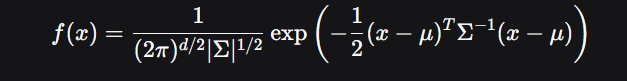

The above image shows what I wanna recreate.

We can see that Class 0's gaussian pdf is very broad-wide and that can also be explained by seeing that the diagonal elements of its covariance matrix C0(0,0) and C0(1,1) are bigger than those of C1 and C2 meaning that its variance will be bigger. Also we can see that Class 1 is the opposite by being very narrow and having the higher 'top' of the 3 pdfs .

END OF 'A'



---



START OF 'B'


Shape: (200, 1)

Describe its statistics:
           values
count  200.000000
mean     0.070186
std      1.972615
min     -5.397045
25%     -1.358560
50%      0.168852
75%      1.472168
max      5.395079

 Check whether we have any missing values:
   NaN values: 0
   Null values: 0


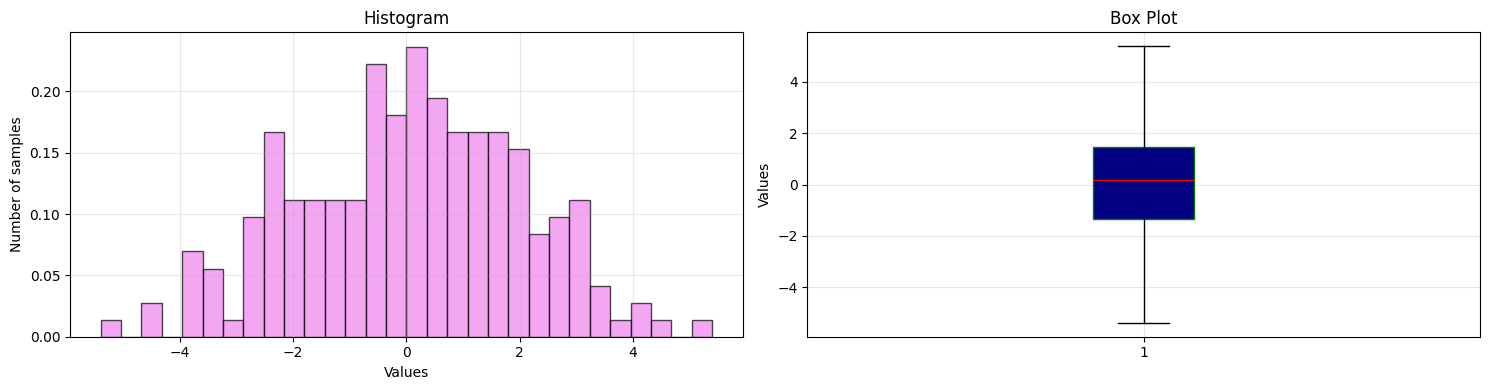


Theoretical pdf: N(1, 4.0)
  mean: 1
  std: 2.0000

Real Data:
  mean: 0.0702
  std: 1.9726
 Mean Difference: 0.9298
 std Difference: 0.0274


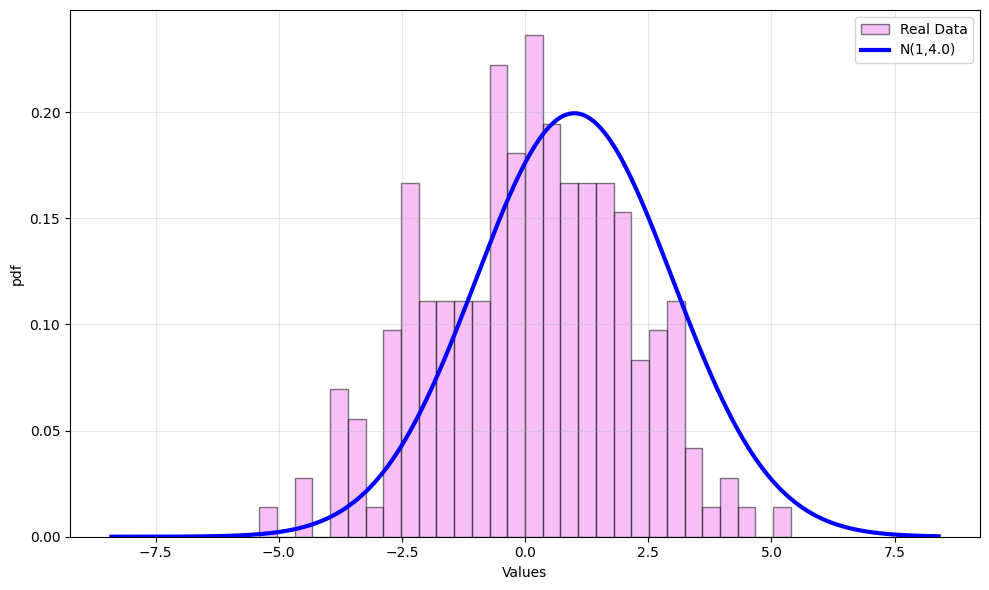


h = 0.1
  True avg log-likelihood     : -2.204124
  Gaussian kernel:
    Pred avg log-likelihood   : -1.954626
    MSE                       : 0.062250
  Hypercube kernel:
    Pred avg log-likelihood   : -1.783275
    MSE                       : 0.177114

h = 0.2
  True avg log-likelihood     : -2.204124
  Gaussian kernel:
    Pred avg log-likelihood   : -2.025144
    MSE                       : 0.032034
  Hypercube kernel:
    Pred avg log-likelihood   : -1.946860
    MSE                       : 0.066185

h = 0.3
  True avg log-likelihood     : -2.204124
  Gaussian kernel:
    Pred avg log-likelihood   : -2.054200
    MSE                       : 0.022477
  Hypercube kernel:
    Pred avg log-likelihood   : -2.012336
    MSE                       : 0.036783

h = 0.4
  True avg log-likelihood     : -2.204124
  Gaussian kernel:
    Pred avg log-likelihood   : -2.070139
    MSE                       : 0.017952
  Hypercube kernel:
    Pred avg log-likelihood   : -1.989804
    MSE          

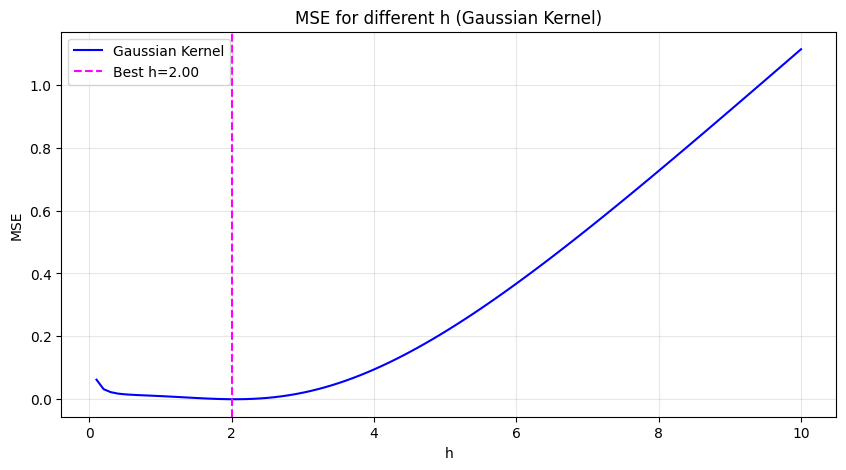

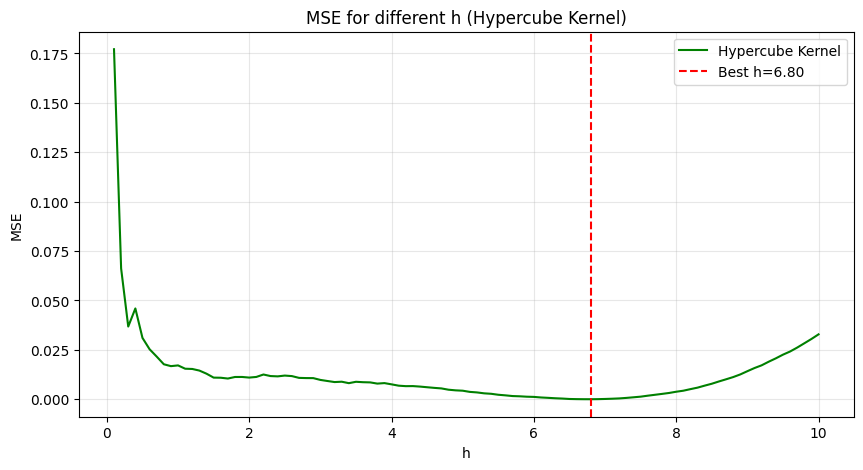

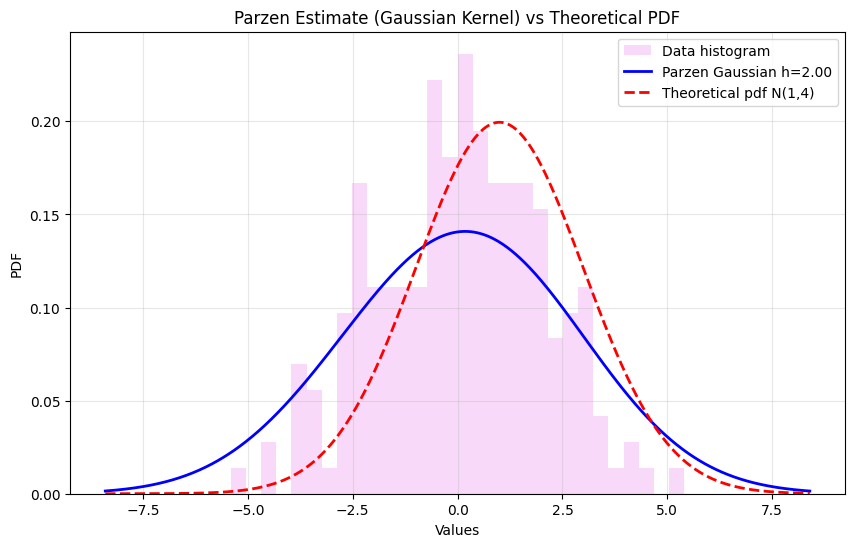

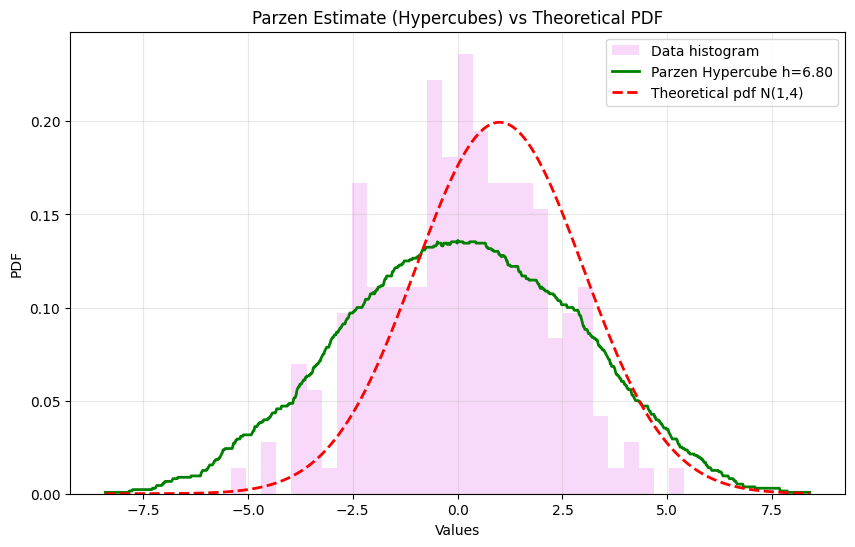

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# again load the data as pd dataframe
df = pd.read_csv('dataset2.csv', header=None, names=['values'])

print(f"\nShape: {df.shape}") #check if the dimensions are matching

print("\nDescribe its statistics:")
print(df.describe())

print("\n Check whether we have any missing values:")
print(f"   NaN values: {df['values'].isna().sum()}")
print(f"   Null values: {df['values'].isnull().sum()}")



#-------------------------------------------------------
# Visualizing our data
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Histogram
axes[0].hist(df['values'], bins=30, density=True, alpha=0.7,
            color='violet', edgecolor='black')
axes[0].set_xlabel('Values')
axes[0].set_ylabel('Number of samples')
axes[0].set_title('Histogram')
axes[0].grid(True, alpha=0.3)

# Box-plot
axes[1].boxplot(df['values'], vert=True, patch_artist=True,
               boxprops=dict(facecolor='navy', color='green'),
               medianprops=dict(color='red'))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Values')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

#----------------------------------------------------------

from scipy.stats import norm
import math

# theoretical values
mean_theoretical = 1
std_theoretical = math.sqrt(4)

# actual values (based on data)
mean_actual = df['values'].mean()
std_actual = df['values'].std()

print(f"\nTheoretical pdf: N({mean_theoretical}, {std_theoretical**2})")
print(f"  mean: {mean_theoretical}")
print(f"  std: {std_theoretical:.4f}")

print(f"\nReal Data:")
print(f"  mean: {mean_actual:.4f}")
print(f"  std: {std_actual:.4f}")


print(f" Mean Difference: {abs(mean_actual - mean_theoretical):.4f}")
print(f" std Difference: {abs(std_actual - std_theoretical):.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df['values'], bins=30, density=True, alpha=0.5,
       color='violet', edgecolor='black', label='Real Data')

x_range = np.linspace(df['values'].min() - 3, df['values'].max() + 3, 1000)
pdf_theoretical = norm.pdf(x_range, loc=mean_theoretical, scale=std_theoretical)

ax.plot(x_range, pdf_theoretical, 'b-', linewidth=3,
        label=f'N({mean_theoretical},{std_theoretical**2})')

ax.set_xlabel('Values')
ax.set_ylabel('pdf')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#-------------------------------------------------------------------
data_array = df['values'].values
n = len(data_array)


def hypercube_kernel(u): #function for hypercube (output-->1 if 0.5 max diff in each direction)
    return 1.0 if abs(u) <= 0.5 else 0.0

def gaussian_kernel(u):
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2) #function for gaussian kernel (smooth-fuzzy)

def parzen_estimate(x_query, data, h, kernel_func):   #approximation of pdf

    n = len(data)
    result = 0.0

    for x_i in data:
        u = (x_query - x_i) / h  #note that because d=1 (feature) h^d=h^1=h
        result += kernel_func(u)

    return result / (n * h)


    #---------------------------------------------------------
h_range = np.arange(0.1, 10.1, 0.1)

# calculate the theoretical likelihood
true_log_likelihood = np.sum(norm.logpdf(data_array, loc=1, scale=2))

#lists for the MSE errors
errors_gaussian = []
errors_hypercube = []

# Loop for all h
for idx, h in enumerate(h_range):
    pred_log_likelihood_gaussian = 0.0
    pred_log_likelihood_hypercube = 0.0
    valid_points_gaussian = 0
    valid_points_hypercube = 0

    for i in range(n):
        x_i = data_array[i]

        # Gaussian Kernel
        pdf_gaussian = parzen_estimate(x_i, data_array, h, gaussian_kernel)
        if pdf_gaussian > 1e-10:  #safety for very small values inside log()
            pred_log_likelihood_gaussian += np.log(pdf_gaussian)
            valid_points_gaussian += 1

        # Hypercubes
        pdf_hypercube = parzen_estimate(x_i, data_array, h, hypercube_kernel)
        if pdf_hypercube > 1e-10:
            pred_log_likelihood_hypercube += np.log(pdf_hypercube)
            valid_points_hypercube += 1

    if valid_points_gaussian > 0:
        avg_pred_gaussian = pred_log_likelihood_gaussian / valid_points_gaussian
        avg_true = true_log_likelihood / n
        error_gaussian = (avg_pred_gaussian - avg_true) ** 2 #MSE error
    else:
        error_gaussian = np.inf

    if valid_points_hypercube > 0:
        avg_pred_hypercube = pred_log_likelihood_hypercube / valid_points_hypercube
        error_hypercube = (avg_pred_hypercube - avg_true) ** 2
    else:
        error_hypercube = np.inf

    errors_gaussian.append(error_gaussian)  #add them to the list
    errors_hypercube.append(error_hypercube)

    print(f"\nh = {h:.1f}")
    print(f"  True avg log-likelihood     : {avg_true:.6f}")

    print(f"  Gaussian kernel:")
    print(f"    Pred avg log-likelihood   : {avg_pred_gaussian:.6f}")
    print(f"    MSE                       : {error_gaussian:.6f}")

    print(f"  Hypercube kernel:")
    print(f"    Pred avg log-likelihood   : {avg_pred_hypercube:.6f}")
    print(f"    MSE                       : {error_hypercube:.6f}")


best_h_gaussian = h_range[np.argmin(errors_gaussian)]
best_h_hypercube = h_range[np.argmin(errors_hypercube)]

print(f"\nBest h for Gaussian kernel: {best_h_gaussian:.2f}")
print(f"Best h for Hypercube kernel: {best_h_hypercube:.2f}")

# Plot MSE for different h values in gaussian
plt.figure(figsize=(10,5))
plt.plot(h_range, errors_gaussian, 'b-', label='Gaussian Kernel')
plt.axvline(best_h_gaussian, color='magenta', linestyle='--', label=f'Best h={best_h_gaussian:.2f}')
plt.xlabel('h')
plt.ylabel('MSE')
plt.title('MSE for different h (Gaussian Kernel)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot MSE for different h values in hypercube
plt.figure(figsize=(10,5))
plt.plot(h_range, errors_hypercube, 'g-', label='Hypercube Kernel')
plt.axvline(best_h_hypercube, color='red', linestyle='--', label=f'Best h={best_h_hypercube:.2f}')
plt.xlabel('h')
plt.ylabel('MSE')
plt.title('MSE for different h (Hypercube Kernel)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#-------------------------
x_range = np.linspace(df['values'].min() - 3, df['values'].max() + 3, 1000)

# Use the best values of h for each kernel
pdf_gaussian_best = [parzen_estimate(x, data_array, best_h_gaussian, gaussian_kernel) for x in x_range]
pdf_hypercube_best = [parzen_estimate(x, data_array, best_h_hypercube, hypercube_kernel) for x in x_range]

# Our given/theoretical pdf
pdf_theoretical = norm.pdf(x_range, loc=1, scale=2)

# Plot Gaussian
plt.figure(figsize=(10,6))
plt.hist(data_array, bins=30, density=True, alpha=0.3, color='violet', label='Data histogram')
plt.plot(x_range, pdf_gaussian_best, 'b-', linewidth=2, label=f'Parzen Gaussian h={best_h_gaussian:.2f}')
plt.plot(x_range, pdf_theoretical, 'r--', linewidth=2, label='Theoretical pdf N(1,4)')
plt.title('Parzen Estimate (Gaussian Kernel) vs Theoretical PDF')
plt.xlabel('Values')
plt.ylabel('PDF')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot for Hypercube
plt.figure(figsize=(10,6))
plt.hist(data_array, bins=30, density=True, alpha=0.3, color='violet', label='Data histogram')
plt.plot(x_range, pdf_hypercube_best, 'g-', linewidth=2, label=f'Parzen Hypercube h={best_h_hypercube:.2f}')
plt.plot(x_range, pdf_theoretical, 'r--', linewidth=2, label='Theoretical pdf N(1,4)')
plt.title('Parzen Estimate (Hypercubes) vs Theoretical PDF')
plt.xlabel('Values')
plt.ylabel('PDF')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



Some added comments:

From the given Histogram, the Box-plot and the knowledge from 'Probabilites and Statistical Analysis' we can consider that pdf a Gaussian, but it is not centered around 1 but around 0.

Moreover, we are theoretically given that s^2=4-->s=2
So the Q1 and Q3 in the boxplot should be 1-0.675*2=-0.35 and 1+2*0.675=2.3 which doesnt seem to match. This could be due to the fact that we dont have 'infinite' samples but only 200, but the fact that the Gaussian isnt centered around 1 seems to be the most 'problematic'

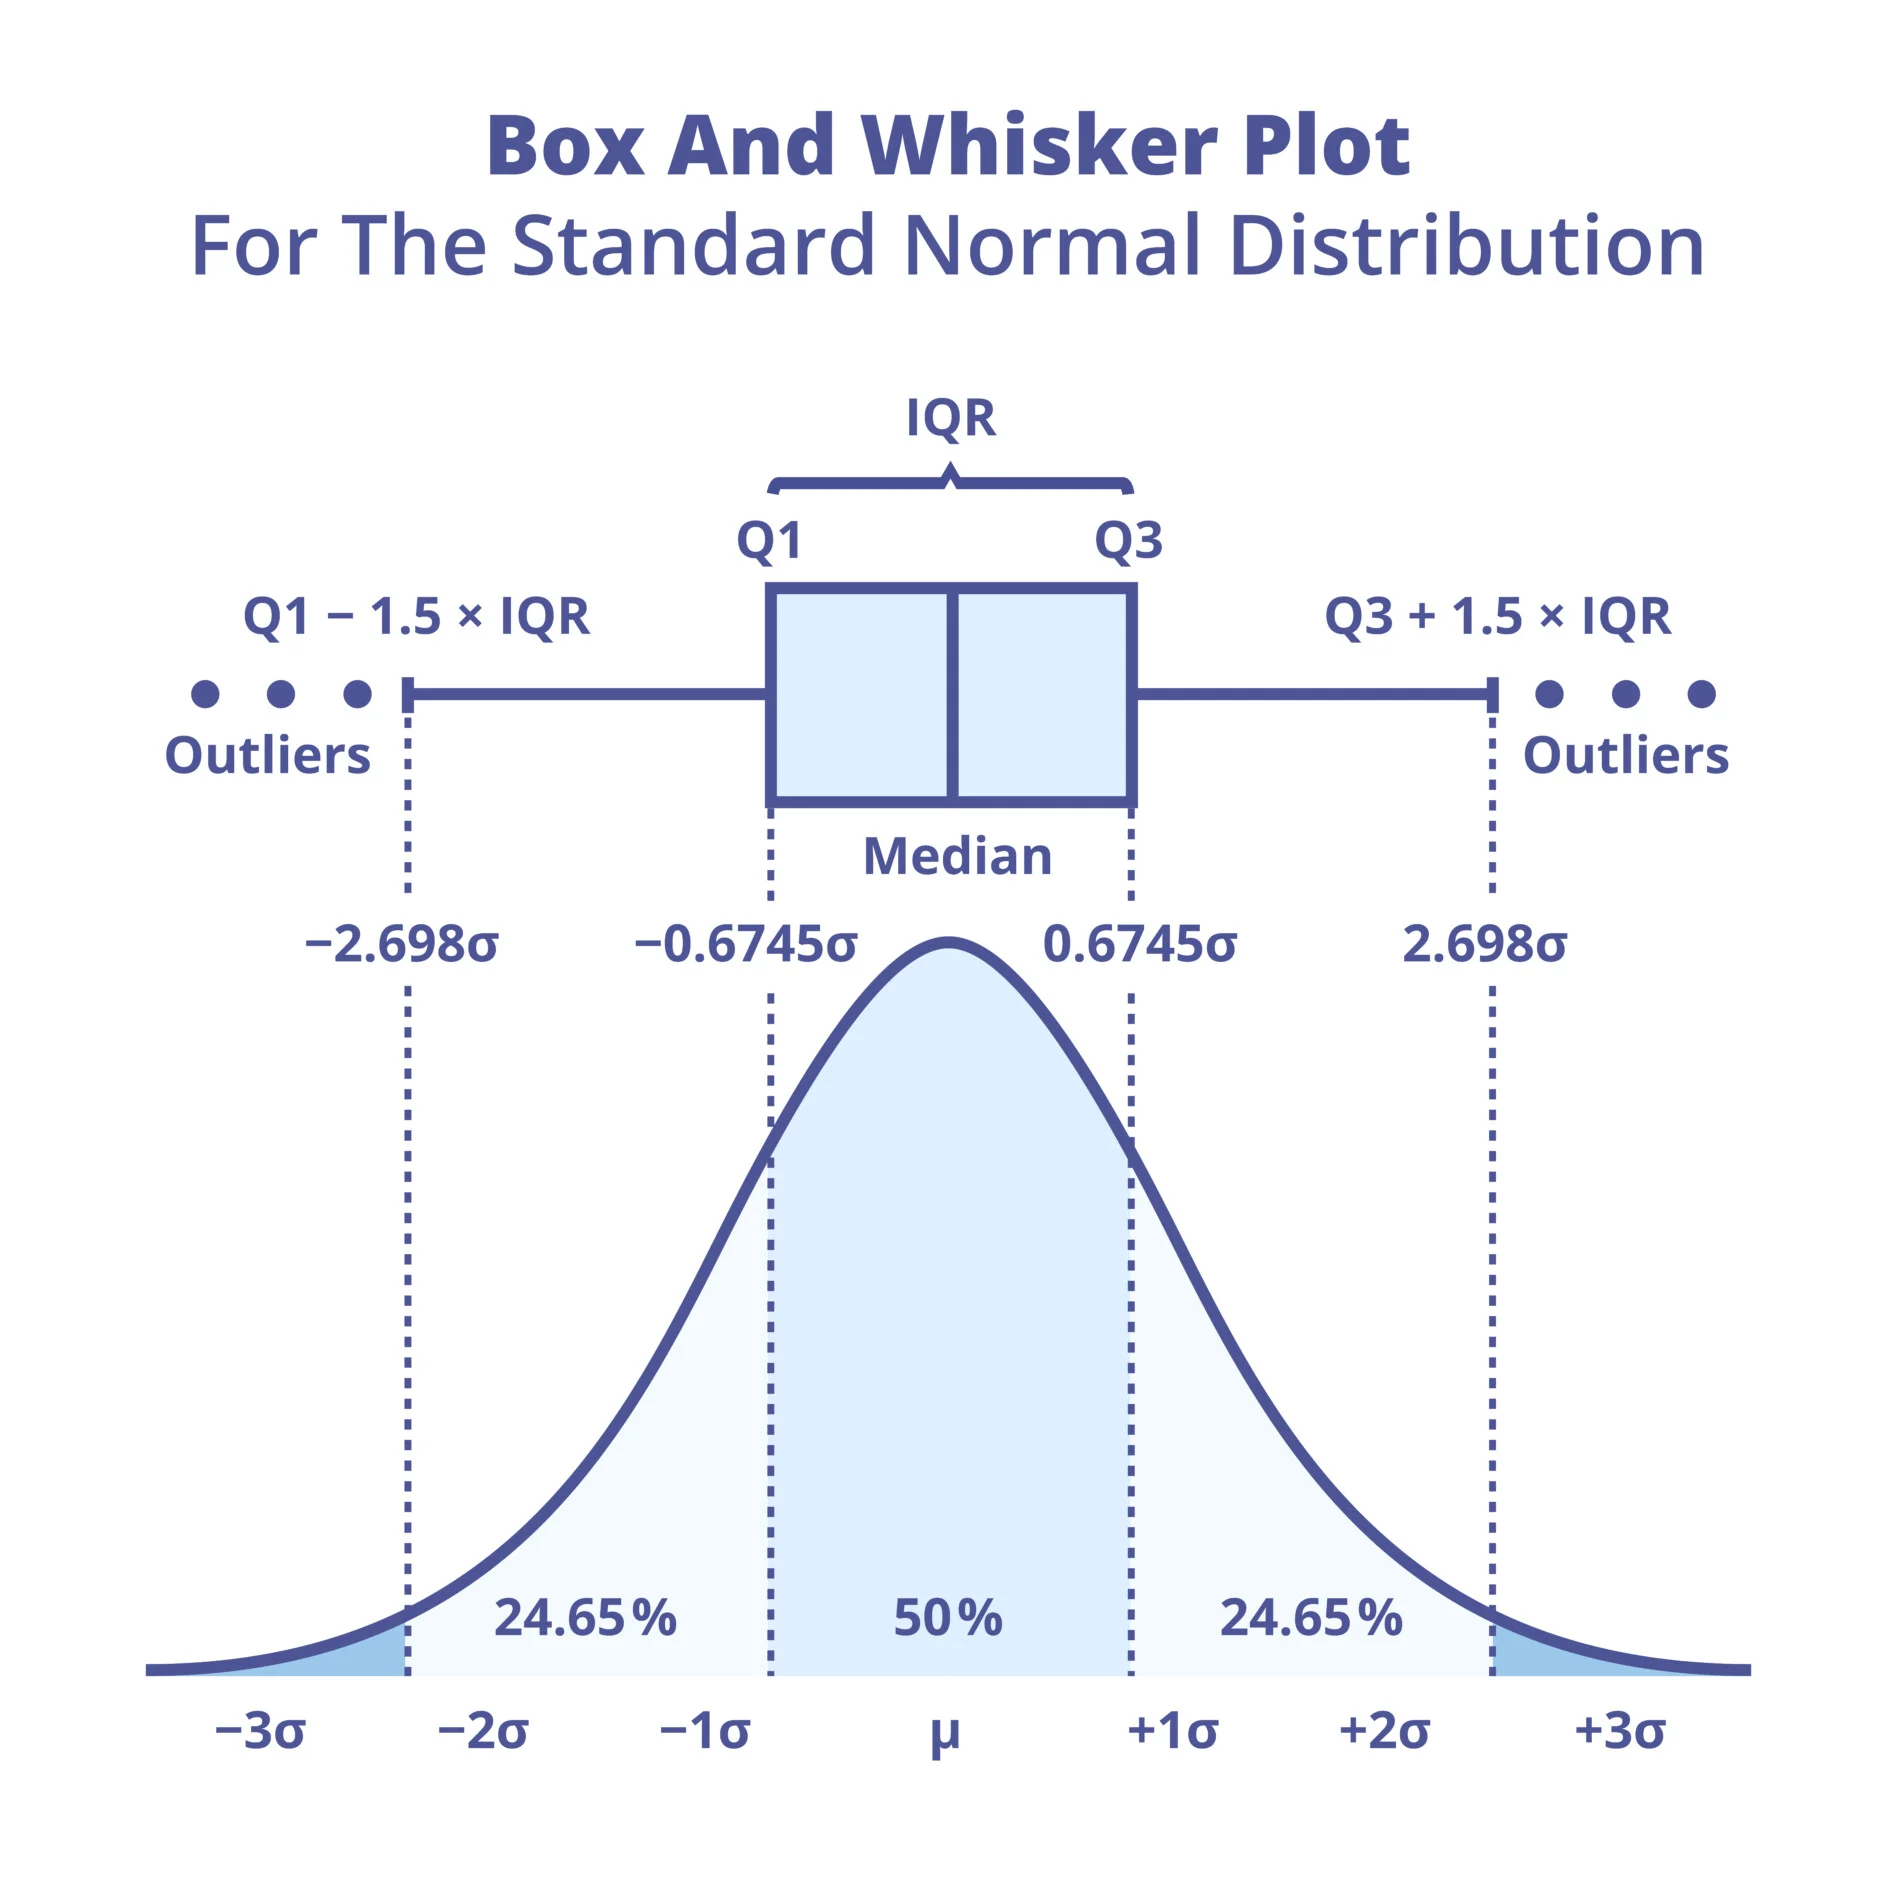

From the above results we can see that indeed the std difference exists but is not so important as the mean difference. The mean value calculated is around 0.07, which means the Gaussian pdf is centered around 0 and not 1.

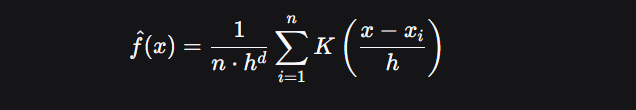

========================================================================
PART C
========================================================================


Best k value: 11
Accuracy for k=11: 0.7400


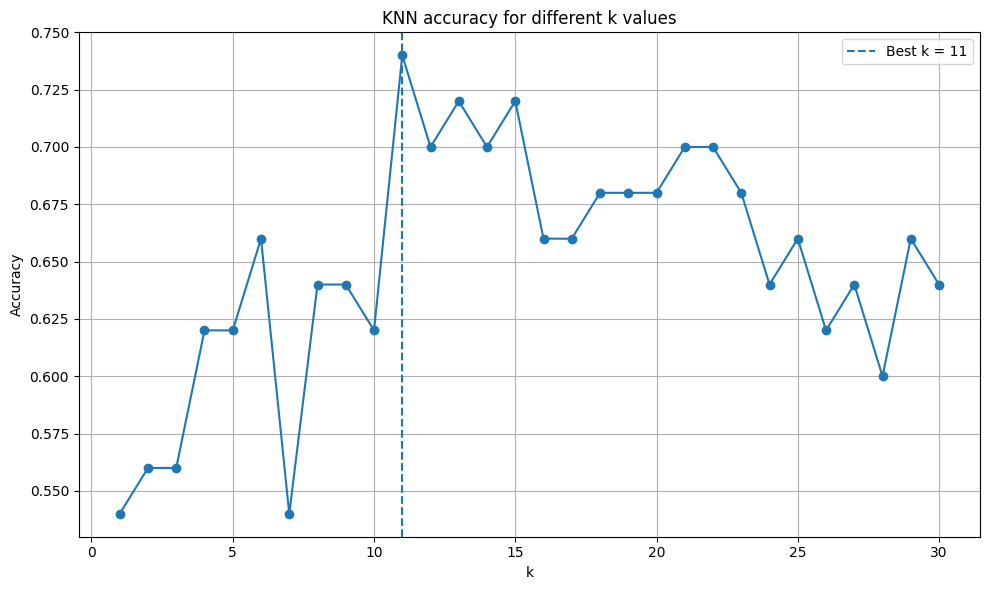

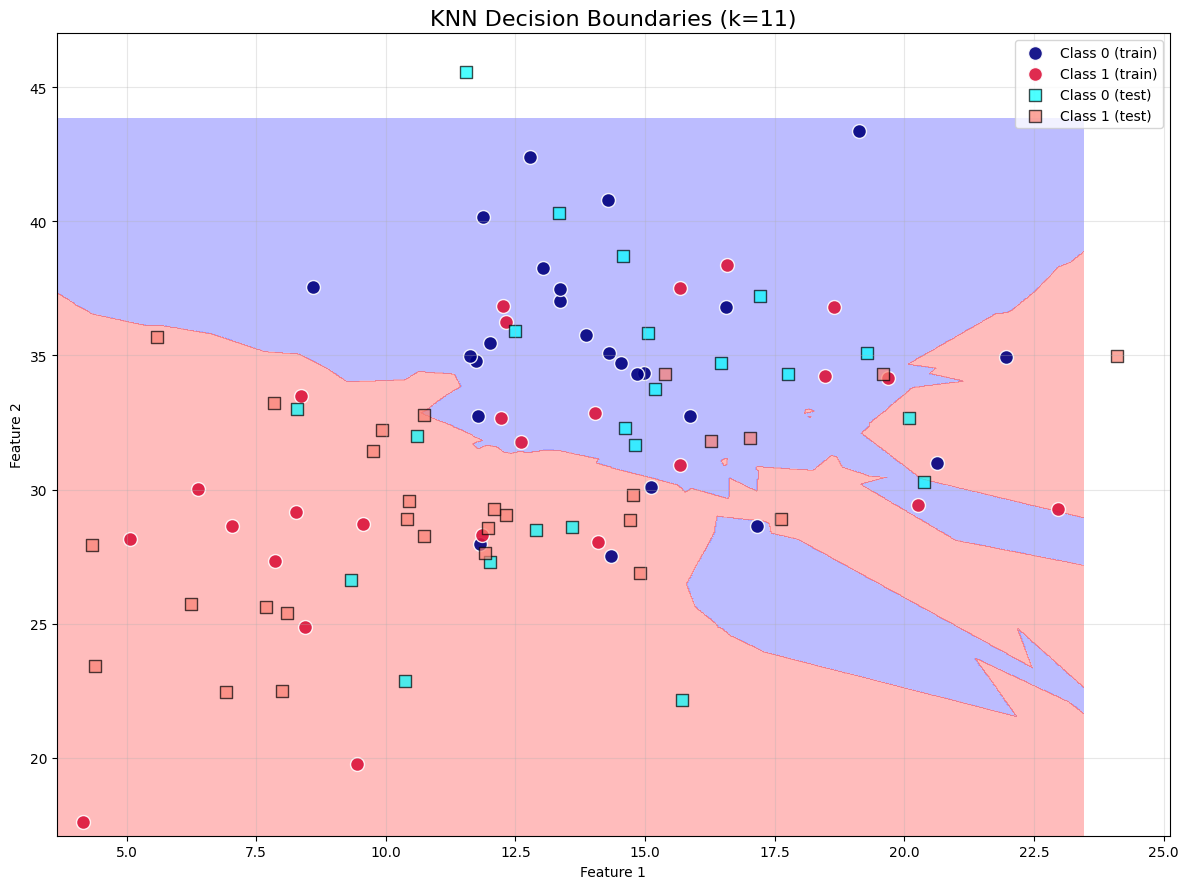

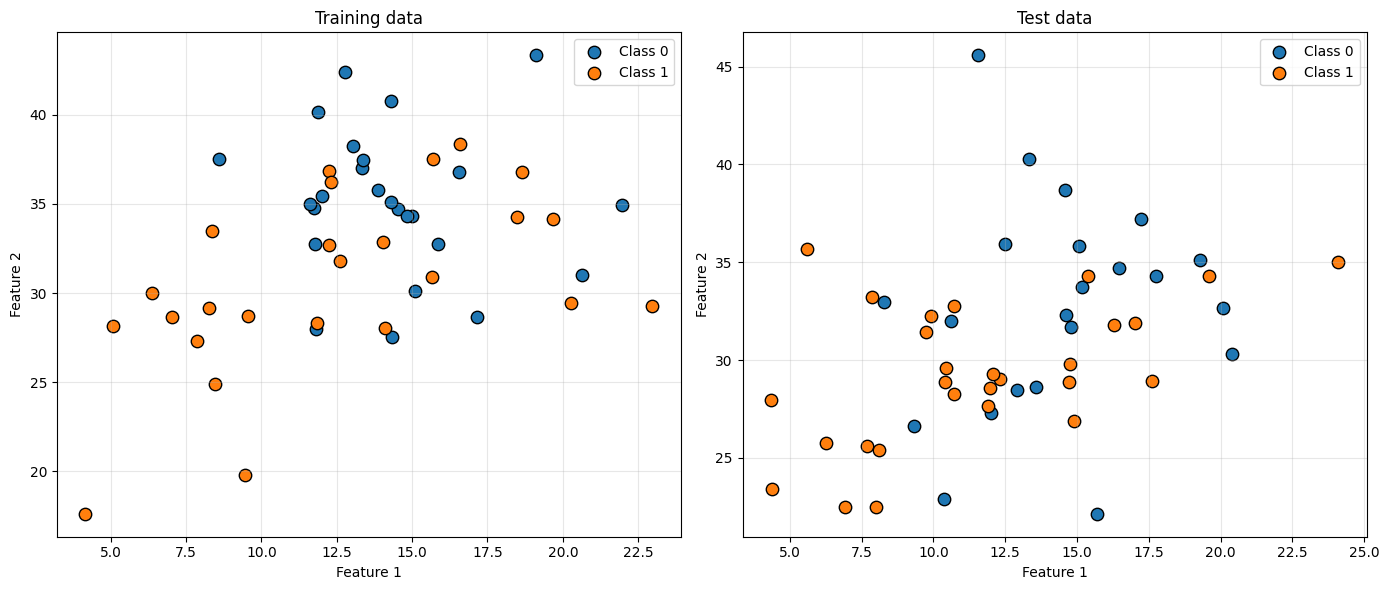

/tmp/ipython-input-3194477402.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([
/tmp/ipython-input-3194477402.py:177: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([


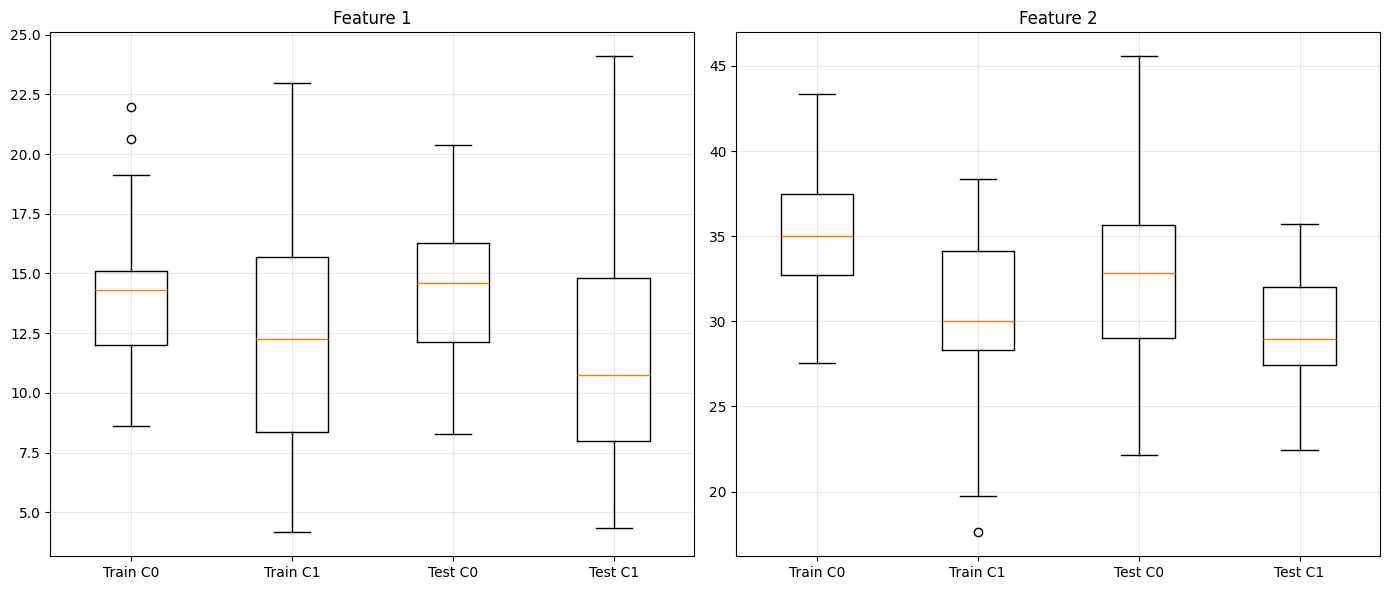

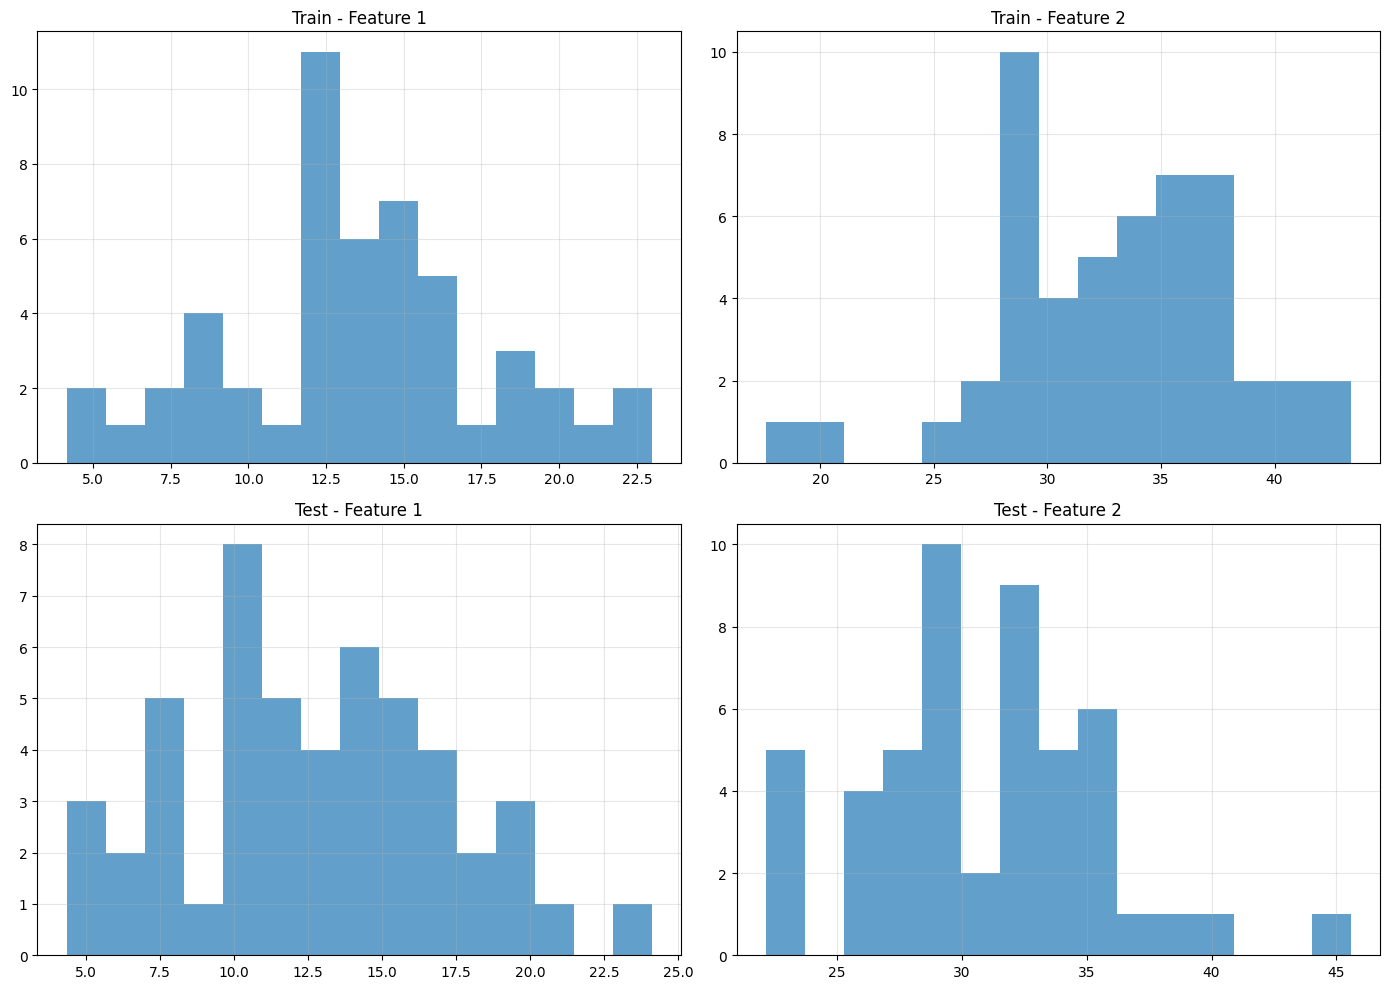

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def eucl(x, trainData):
    squared_diff = (x - trainData) ** 2
    sum_squared_diff = np.sum(squared_diff, axis=1) #calculate the sum of all the distances
    distances = np.sqrt(sum_squared_diff)
    return distances


def neighbors(x, trainData, k):
    distances = eucl(x, trainData) #use the previously made function

    # Sort distances in descending order (as requested-just technical issue)
    sorted_indices = np.argsort(distances)[::-1]

    # Select the last k indices (because we want the smallest distance and have already put them in descending order)
    k_nearest_indices = sorted_indices[-k:]  # start from back from last till [-k=k before last]

    return k_nearest_indices


def predict(testData, trainData, trainLabels, k):
    n_test = testData.shape[0]
    probabilities = np.zeros((n_test, 2))

    for i in range(n_test):
        x = testData[i]

        nearest_indices = neighbors(x, trainData, k) #find the k nearest
        nearest_labels = trainLabels[nearest_indices] #and check their labels

        count_class0 = np.sum(nearest_labels == 0) #we sum the neighbors of label 0
        count_class1 = np.sum(nearest_labels == 1) #and of label 1

        probabilities[i, 0] = count_class0 / k #we NORMALIZE with k and bcs countclass0+countclass1=k it sums up to 1(like the probability)
        probabilities[i, 1] = count_class1 / k

    return probabilities




train_df = pd.read_csv('dataset3.csv', header=None)
test_df = pd.read_csv('testset.csv', header=None)

X_train = train_df.iloc[:, :2].values  #keep the label out
y_train = train_df.iloc[:, 2].values

X_test = test_df.iloc[:, :2].values
y_test = test_df.iloc[:, 2].values


k_values = range(1, 31) #we are asked to try for these values of k-neighbors
accuracies = [] #make a list to calculate the accuraccies

for k in k_values:
    probs = predict(X_test, X_train, y_train, k)
    predictions = np.argmax(probs, axis=1) #In case of same number of votes argmax just returns the 1st value (which is no problem as they have the same 'votes')
    accuracy = np.mean(predictions == y_test)
    accuracies.append(accuracy)

best_k_index = np.argmax(accuracies)
best_k = list(k_values)[best_k_index]
best_accuracy = accuracies[best_k_index]

print(f"Best k value: {best_k}")
print(f"Accuracy for k={best_k}: {best_accuracy:.4f}")


# Plot accuracy for different k-neighbors values
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('KNN accuracy for different k values')
plt.grid(True)
plt.axvline(best_k, linestyle='--', label=f'Best k = {best_k}')
plt.legend()
plt.tight_layout()
plt.show()


# Decision boundaries k=11
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_probs = predict(grid_points, X_train, y_train, best_k)
grid_predictions = np.argmax(grid_probs, axis=1)
Z = grid_predictions.reshape(xx.shape)

plt.figure(figsize=(12, 9))

# Decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.bwr)

plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c='navy', edgecolors='white', s=100, label='Class 0 (train)', marker='o', alpha=0.9)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c='crimson', edgecolors='white', s=100, label='Class 1 (train)', marker='o', alpha=0.9)

plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
            c='cyan', edgecolors='black', s=80, label='Class 0 (test)', marker='s', alpha=0.7)
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
            c='salmon', edgecolors='black', s=80, label='Class 1 (test)', marker='s', alpha=0.7)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'KNN Decision Boundaries (k={best_k})', fontsize=16)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#--------------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load data
train_df = pd.read_csv('dataset3.csv', header=None)
test_df = pd.read_csv('testset.csv', header=None)

X_train = train_df.iloc[:, :2].values
y_train = train_df.iloc[:, 2].values

X_test = test_df.iloc[:, :2].values
y_test = test_df.iloc[:, 2].values


# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
                edgecolors='k', s=80, label='Class 0')
axes[0].scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
                edgecolors='k', s=80, label='Class 1')
axes[0].set_title('Training data')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
                edgecolors='k', s=80, label='Class 0')
axes[1].scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
                edgecolors='k', s=80, label='Class 1')
axes[1].set_title('Test data')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Also lets check boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].boxplot([
    X_train[y_train == 0, 0],
    X_train[y_train == 1, 0],
    X_test[y_test == 0, 0],
    X_test[y_test == 1, 0]
], labels=['Train C0', 'Train C1', 'Test C0', 'Test C1'])
axes[0].set_title('Feature 1')

axes[1].boxplot([
    X_train[y_train == 0, 1],
    X_train[y_train == 1, 1],
    X_test[y_test == 0, 1],
    X_test[y_test == 1, 1]
], labels=['Train C0', 'Train C1', 'Test C0', 'Test C1'])
axes[1].set_title('Feature 2')

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Histrogram
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(X_train[:, 0], bins=15, alpha=0.7)
axes[0, 0].set_title('Train - Feature 1')

axes[0, 1].hist(X_train[:, 1], bins=15, alpha=0.7)
axes[0, 1].set_title('Train - Feature 2')

axes[1, 0].hist(X_test[:, 0], bins=15, alpha=0.7)
axes[1, 0].set_title('Test - Feature 1')

axes[1, 1].hist(X_test[:, 1], bins=15, alpha=0.7)
axes[1, 1].set_title('Test - Feature 2')

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Lets explain why we find the 'optimal' k in between the min and max values tested.
When k in KNN is very small the classifier only looks at the nearest neighbor so it can easily overfit the training data and the decision boundaries are very jagged.
When k is very large, close to the total number of training points, the classifier tends to underfit because it considers almost all points, ignoring small patterns, and the decision boundaries become very smooth and simple.

I wanted to check why the accuraccy was at that level. So I plot the data of train and test (although that can be considered peeking I do it just to see why we maxed at 75%) and also check the boxplots and the histograms.

problematic boxplots.
can also be explained bcs in the TEST VISUAL we can see some datapoints of either class 0 or 1 that we hadnt seen in the TRAIN.
Thus its either out of distribution or our estimation for the original train distribution was not sufficient enough.
(in any case train=test and thats not the best)

It seems like the estimation of the pdf was not 'sufficient' as it doesnt seem to match the one of the incoming-test data , and thats why we maximize at 75%, if the pdf (histogram/boxplot) of the train data and test data had 'similar' shapes we would expect better data (similar!=same bcs then we would just memorize our train data)